# **03. Statistical analysis**

In this notebook, a deeper statistical analysis is performed on the data.

In [1]:
import sys
sys.path.append('../src')
from models import SalesRecord, ReturnRecord, Invoice

import pandas as pd
import sqlite3
from sqlalchemy import create_engine
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from scipy import stats

In [2]:
df_sales = pd.read_csv("../data/sales_clean.csv",dtype={"Customer ID": "str"})
df_returns = pd.read_csv("../data/returns_clean.csv",dtype={"Customer ID": "str"})
df_sales["InvoiceDate"] = pd.to_datetime(df_sales["InvoiceDate"])

In [3]:
# create SQLite database
engine = create_engine("sqlite:///../data/retail.db")

# load dataframes
df_sales.to_sql('sales', engine, if_exists='replace', index=False)
df_returns.to_sql('returns', engine, if_exists='replace', index=False)

17915

## 3.1 Distributions

In this first section we examine in more detail the sales revenue by customer and by products, to better understand their distribution and confirm what we previously found through Pareto analysis. What we expect to find is that most customers spend lower amounts of money, and that most products cost a lower amount, confirming the Pareto findings that suggest that most of the revenue is accounted for by a low amount of both customers and products.

### 3.1.1 Revenue per customer

In [132]:
df_cust_sal = pd.read_csv("../data/cust_sales.csv",dtype={"Customer ID": "str"})

In [133]:
pareto_point = df_cust_sal[df_cust_sal["cumulative_pct"]>=80].iloc[0]
pareto_revenue = df_cust_sal[df_cust_sal["customer_pct"] <= pareto_point["customer_pct"]]["revenue"].min()

Text(0.5, 1.0, 'Customer Revenue Distribution (log scale)')

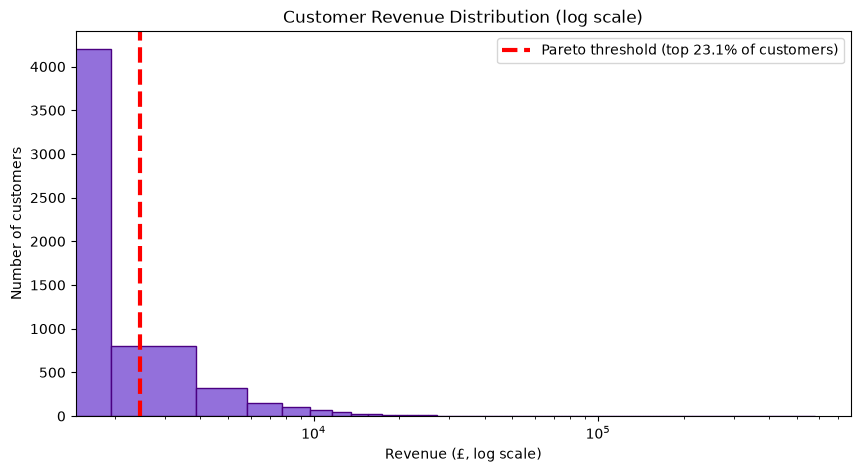

In [134]:
plt.figure(figsize=(10,5))
cust_sal_h, bins, _ = plt.hist(df_cust_sal["revenue"], bins=300, color="mediumpurple", edgecolor="indigo")
plt.xscale("log")
plt.axvline(x=pareto_revenue, color='red', linestyle='--', label=f'Pareto threshold (top {pareto_point["customer_pct"]:.1f}% of customers)',linewidth=3)
plt.legend()
plt.xlabel("Revenue (£, log scale)")
plt.ylabel("Number of customers")
plt.title("Customer Revenue Distribution (log scale)")

In [135]:
print(f"Mean: £{df_cust_sal['revenue'].mean():,.0f}")
print(f"Median: £{df_cust_sal['revenue'].median():,.0f}")
print(f"Skewness: {df_cust_sal['revenue'].skew():.2f}")

Mean: £2,916
Median: £856
Skewness: 25.33


The revenue distribution is heavily right-skewed, with a skewness of 25.33. This informs us of the fact that the majority of customers spend a lower amount (the median in this case is more informative than the mean) and suggests that only few customers contribute to the majority of the revenue.    

This is consistent with the Pareto finding: the long right tail represents the small fraction of high-spending customers that account for the majority of total revenue.    

For a clearer visualization, let us see the logarithmic distribution of the revenue.

Text(0.5, 1.0, 'Customers Revenue Distribution (log scale)')

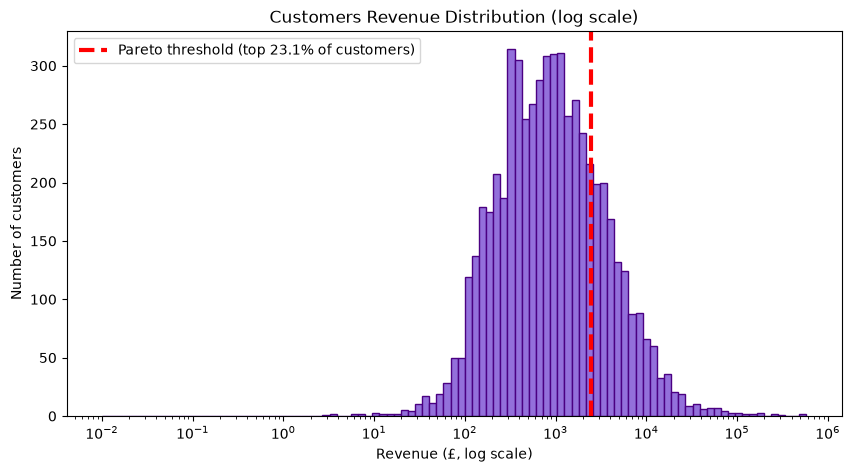

In [136]:
plt.figure(figsize=(10,5))
bins = np.logspace(np.log10(df_cust_sal["revenue"].min()+0.01), 
                   np.log10(df_cust_sal["revenue"].max()), 
                   100)
cust_sal_h = plt.hist(df_cust_sal["revenue"], bins=bins,color="mediumpurple", edgecolor="indigo" )
plt.xscale("log")
plt.axvline(x=pareto_revenue, color='red', linestyle='--', label=f'Pareto threshold (top {pareto_point["customer_pct"]:.1f}% of customers)',linewidth=3)
plt.legend()
plt.xlabel("Revenue (£, log scale)")
plt.ylabel("Number of customers")
plt.title("Customers Revenue Distribution (log scale)")


### 3.1.2 Revenue per product

In [137]:
df_prod_sal = pd.read_csv('../data/prod_sales.csv')

In [138]:
pareto_point = df_prod_sal[df_prod_sal["cumulative_pct"]>=80].iloc[0]
pareto_revenue = df_prod_sal[df_prod_sal["product_pct"] <= pareto_point["product_pct"]]["revenue"].min()

Text(0.5, 1.0, 'Products Revenue Distribution (log scale)')

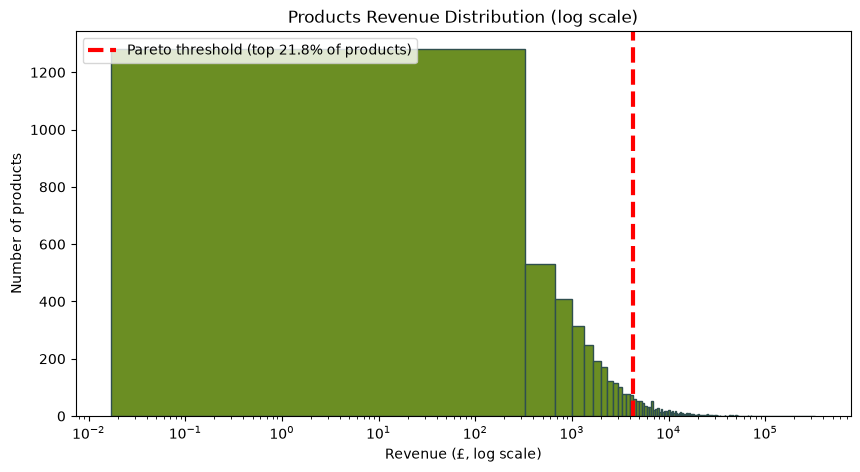

In [139]:
plt.figure(figsize=(10,5))
prod_rev_h, bins, _ = plt.hist(df_prod_sal["revenue"], bins=1000, color="olivedrab", edgecolor="darkslategrey")
plt.axvline(x=pareto_revenue, color='red', linestyle='--', label=f'Pareto threshold (top {pareto_point["product_pct"]:.1f}% of products)', linewidth = 3)
plt.legend()
plt.xscale("log")
plt.xlabel("Revenue (£, log scale)")
plt.ylabel("Number of products")
plt.title("Products Revenue Distribution (log scale)")

In [140]:
print(f"Mean: £{df_prod_sal['revenue'].mean():,.0f}")
print(f"Median: £{df_prod_sal['revenue'].median():,.0f}")
print(f"Skewness: {df_prod_sal['revenue'].skew():.2f}")

Mean: £4,157
Median: £1,126
Skewness: 11.99


The revenue distribution by products is also right-skewed, with a skewness of 11.99. This informs us of the fact that the majority of products cost a less than £$100$ and is consistent with the Pareto finding: the long right tail represents the small fraction of high-costing products that account for the majority of total revenue.    

For a clearer visualization, let us see the logarithmic distribution of the revenue.

Text(0.5, 1.0, 'Products Revenue Distribution (log scale)')

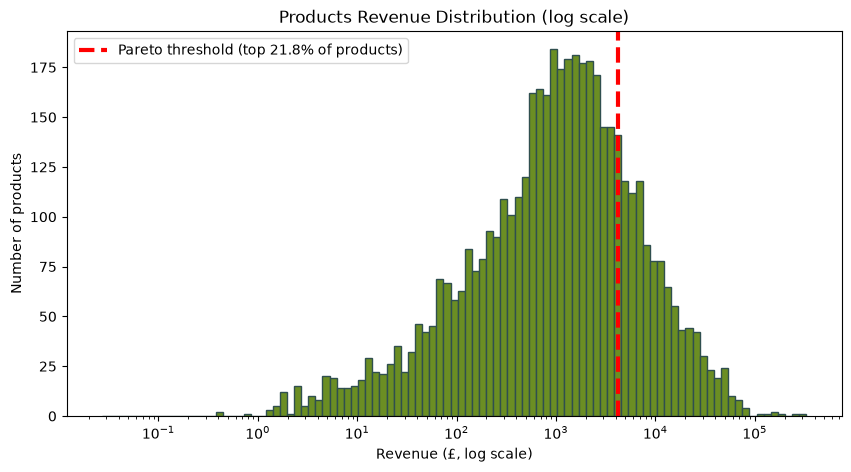

In [126]:
plt.figure(figsize=(10,5))
bins = np.logspace(np.log10(df_prod_sal["revenue"].min()+0.01), 
                   np.log10(df_prod_sal["revenue"].max()), 
                   100)
prod_rev_h = plt.hist(df_prod_sal["revenue"], bins=bins,color="olivedrab", edgecolor="darkslategrey")
plt.xscale("log")
plt.axvline(x=pareto_revenue, color='red', linestyle='--', label=f'Pareto threshold (top {pareto_point["product_pct"]:.1f}% of products)', linewidth = 3)
plt.legend()
plt.xlabel("Revenue (£, log scale)")
plt.ylabel("Number of products")
plt.title("Products Revenue Distribution (log scale)")


## 3.2 RFM Analysis

In this section, we segment the customers by computing their RFM score.    
Each customer will be assigned a score from 1 to 5 on each of three dimensions:    
- **Recency**: how recently the customer made a purchase; a score of 5 indicates a very recent purchase, 1 indicates a long time ago.
- **Frequency**: how often the customer purchases; a score of 5 indicates a very frequent buyer, 1 indicates a one-time or rare buyer.
- **Monetary value**: how much the customer has spent in total; a score of 5 indicates a high-spending customer, 1 indicates a low-spending customer
    
The three scores are then combined into an overall RFM score, which allows us to segment the customer base into meaningful groups such as top customers, at-risk customers, and occasional buyers.

In [10]:
q_rfm = """
    SELECT "Customer ID", MAX(InvoiceDate) AS last_purchase, COUNT(DISTINCT(Invoice)) AS frequency, SUM(Price*QUantity) AS monetary
    FROM sales
    WHERE "Customer ID" IS NOT NULL
    GROUP BY "Customer ID"
    """

df_rfm = pd.read_sql(q_rfm, engine)
df_rfm["last_purchase"] = pd.to_datetime(df_rfm["last_purchase"])

In [11]:
# Compute recency
recent_date = df_rfm['last_purchase'].max()
df_rfm['recency'] = df_rfm['last_purchase'].apply(lambda x: (recent_date - x).days)
df_rfm.head()


,Customer ID,last_purchase,frequency,monetary,recency
0,12346.0,2011-01-18 10:01:00,3,77352.96,325
1,12347.0,2011-12-07 15:52:00,8,4921.53,1
2,12348.0,2011-09-25 13:13:00,5,1658.40,74
3,12349.0,2011-11-21 09:51:00,3,3678.69,18
4,12350.0,2011-02-02 16:01:00,1,294.40,309


In [ ]:
# Assign 1-5 score for each dimension based on quantile subdivision
df_rfm['R_score'] = pd.qcut(df_rfm['recency'], q=5, labels=[5,4,3,2,1])
df_rfm['F_score'] = pd.qcut(df_rfm['frequency'].rank(method='first'), q=5, labels=[1,2,3,4,5])
df_rfm['M_score'] = pd.qcut(df_rfm['monetary'].rank(method='first'), q=5, labels=[1,2,3,4,5])

In [13]:
# Assign customer segment
df_rfm['RFM_segment'] = df_rfm['R_score'].astype(str) + df_rfm['F_score'].astype(str) + df_rfm['M_score'].astype(str)

In [14]:
df_rfm.head()

,Customer ID,last_purchase,frequency,monetary,recency,R_score,F_score,M_score,RFM_segment
0,12346.0,2011-01-18 10:01:00,3,77352.96,325,2,3,5,235
1,12347.0,2011-12-07 15:52:00,8,4921.53,1,5,4,5,545
2,12348.0,2011-09-25 13:13:00,5,1658.40,74,3,4,4,344
3,12349.0,2011-11-21 09:51:00,3,3678.69,18,5,3,5,535
4,12350.0,2011-02-02 16:01:00,1,294.40,309,2,1,2,212


In [15]:
def segment_customer(row):
    r, f, m = row['R_score'], row['F_score'], row['M_score']
    if r>=4 and f>=4 and m>=4:
        return 'Champions'
    elif r >= 3 and f >= 3:
        return 'Loyal Customers'
    elif r >= 4 and f <= 2:
        return 'New Customers'
    elif r <= 2 and f >= 3:
        return 'At Risk'
    elif r <= 2 and f <= 2:
        return 'Lost'
    else:
        return 'Potential Loyalists'

df_rfm['segment'] = df_rfm.apply(segment_customer, axis=1)

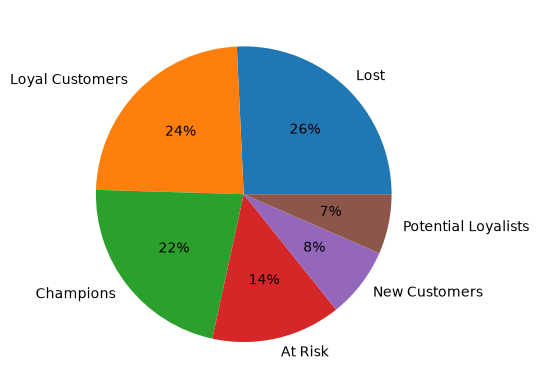

In [16]:
plt.pie(df_rfm.segment.value_counts(),
        labels=df_rfm.segment.value_counts().index,
        autopct='%.0f%%')
plt.show()

The RFM analysis shows that almost half of the total customer-base ($46$%) is highly loyal; among them, almost half is also high-spending ($22$% of the total).    
Of the remaining $54$%, of particular interest is the number of lost clients which amounts to 1/4 of the total customer-base, while the percentage of new customers is only $8$%.    
    
The following heatmap shows the correlation between Recency, Frequency and Monetary:

Text(0.5, 1.0, 'RFM Correlation Matrix')

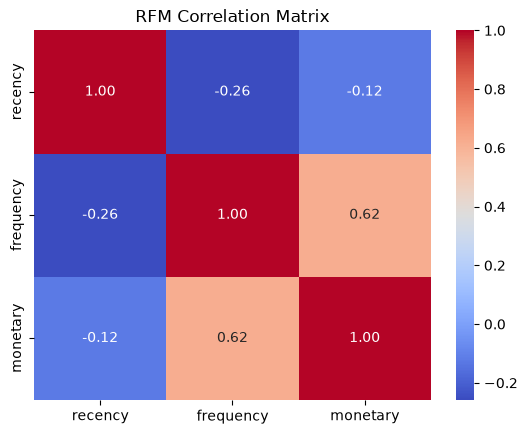

In [17]:
corr_matrix = df_rfm[["recency", "frequency", "monetary"]].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm')
plt.title("RFM Correlation Matrix")

While there is no significant correlation between Monetary and Recency (-0.12) or Frequency and Recency (-0.26), there is a moderate positive correlation of 0.62 between Frequency and Monetary. This suggests that customers who purchase more often also tend to spend more in total, which is expected in a retail context but confirms that frequency is a meaningful predictor of customer value.

## 3.3 Q4 revenue test